In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [42]:
calib = [
[4,  3272, 3286],
[3,  2927, 2919],
[2,  2465, 2465],
[1, 2011, 2013],
[-3, 158, 197],
[-2, 595, 621],
[-1, 1029, 1045],
[-0.9, 1075 , 1087],
[-0.8, 1119, 1129],
[-0.7, 1163, 1173],
[-0.6, 1207, 1216],
[-0.5, 1253, 1259],
[-0.4, 1298, 1303],
[-0.3, 1343, 1347],
[-0.2, 1388, 1391],
[-0.1, 1435, 1436],
[0.1, 1525, 1524],
[0.2, 1572, 1570],
[0.3, 1618, 1613],
[0.4, 1662, 1656],
[0.5, 1707, 1700],
[0.6, 1751, 1743],
[0.7, 1797, 1788],
[0.8, 1843, 1832],
[0.9, 1913, 1876],
]

In [43]:
calib = sorted(calib, key=lambda x: x[0])

mA, Lcodes, Rcodes = zip(*calib)

In [44]:
assert all(np.array(Lcodes[1:])-np.array(Lcodes[:-1]) > 0)
assert all(np.array(Rcodes[1:])-np.array(Rcodes[:-1]) > 0)

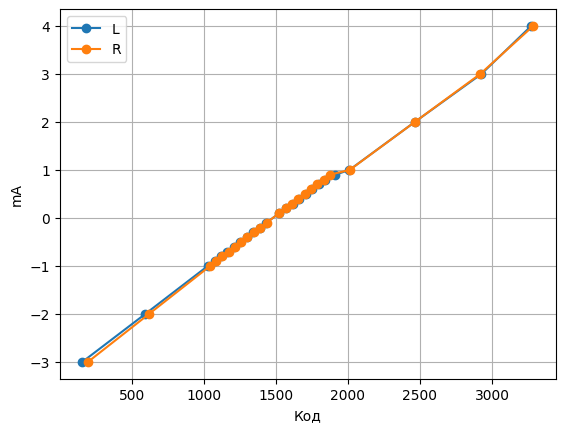

In [45]:
plt.plot(Lcodes, mA, 'o-', label='L')
plt.plot(Rcodes, mA, 'o-', label='R')
plt.legend()
plt.xlabel('Код')
plt.ylabel('mA')
plt.grid()
plt.show()

In [46]:
N_CODES = 4096
code_axis = np.arange(N_CODES, dtype=np.float64)


def cal_table_from_points(codes, ma, n=N_CODES):
    """mA = f(ADC code): линейная интерполяция + линейная экстраполяция за краями."""
    x = np.asarray(codes, dtype=np.float64)
    y = np.asarray(ma, dtype=np.float64)
    order = np.argsort(x)
    x, y = x[order], y[order]
    # дубликаты кодов (если вдруг) — усредняем mA
    xu, inv = np.unique(x, return_inverse=True)
    if len(xu) < len(x):
        yu = np.zeros_like(xu)
        cnt = np.zeros_like(xu)
        for i, j in enumerate(inv):
            yu[j] += y[i]
            cnt[j] += 1
        y = yu / cnt
        x = xu
    f = interp1d(x, y, kind="linear", fill_value="extrapolate", bounds_error=False)
    return f(code_axis)



mean_codes = (np.array(Lcodes)+np.array(Rcodes))/2
cal_l = cal_table_from_points(Lcodes, mA)
cal_r = cal_table_from_points(Rcodes, mA)
cal_mean = cal_table_from_points(mean_codes, mA)


In [47]:
err_l = (cal_l - cal_mean)
err_r = (cal_r - cal_mean)

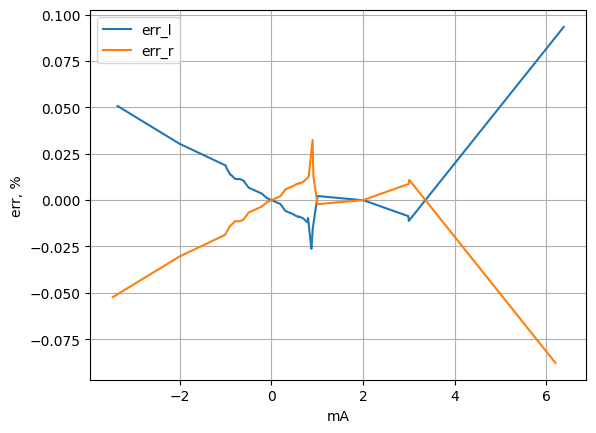

In [48]:
plt.plot(cal_l, err_l, label='err_l')
plt.plot(cal_r, err_r, label='err_r')
plt.legend()
plt.xlabel('mA')
plt.ylabel('err, %')
plt.grid()
plt.show()


In [49]:
print([round(float(v), 3) for v in cal_mean])
np.array(cal_mean, dtype=np.float32).tofile('../presets/ADC_cal.bin')

[-3.412, -3.41, -3.408, -3.405, -3.403, -3.401, -3.398, -3.396, -3.394, -3.391, -3.389, -3.387, -3.384, -3.382, -3.38, -3.377, -3.375, -3.373, -3.37, -3.368, -3.366, -3.364, -3.361, -3.359, -3.357, -3.354, -3.352, -3.35, -3.347, -3.345, -3.343, -3.34, -3.338, -3.336, -3.333, -3.331, -3.329, -3.326, -3.324, -3.322, -3.319, -3.317, -3.315, -3.312, -3.31, -3.308, -3.305, -3.303, -3.301, -3.298, -3.296, -3.294, -3.292, -3.289, -3.287, -3.285, -3.282, -3.28, -3.278, -3.275, -3.273, -3.271, -3.268, -3.266, -3.264, -3.261, -3.259, -3.257, -3.254, -3.252, -3.25, -3.247, -3.245, -3.243, -3.24, -3.238, -3.236, -3.233, -3.231, -3.229, -3.226, -3.224, -3.222, -3.22, -3.217, -3.215, -3.213, -3.21, -3.208, -3.206, -3.203, -3.201, -3.199, -3.196, -3.194, -3.192, -3.189, -3.187, -3.185, -3.182, -3.18, -3.178, -3.175, -3.173, -3.171, -3.168, -3.166, -3.164, -3.161, -3.159, -3.157, -3.154, -3.152, -3.15, -3.148, -3.145, -3.143, -3.141, -3.138, -3.136, -3.134, -3.131, -3.129, -3.127, -3.124, -3.122, -3.1

In [50]:
len(cal_mean)

4096